<a href="https://colab.research.google.com/github/jensjose07/deep_learning_lab/blob/main/Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

           ORIGINAL MNIST DATASET
Original Training Data Shape : (60000, 28, 28)
Original Testing Data Shape  : (10000, 28, 28)

        SELECTED DIGITS: 0, 1, 2
Training Data Shape : (18623, 28, 28)
Testing Data Shape  : (3147, 28, 28)


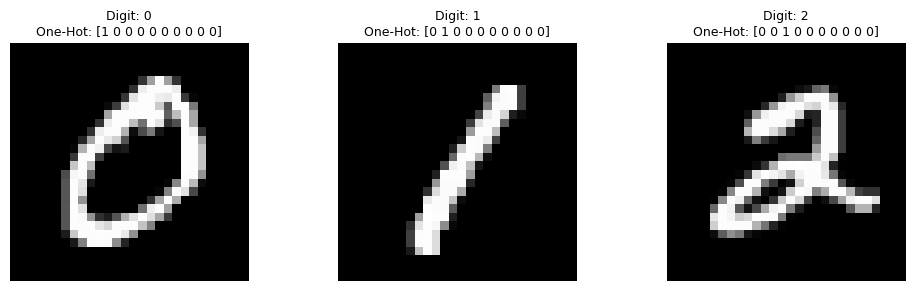


                  MODEL 1 RESULTS

Test Accuracy : 99.94 %
Test Loss     : 0.0021

One-Hot Encoding
----------------------------
Digit 0 -> [1 0 0 0 0 0 0 0 0 0]
Digit 1 -> [0 1 0 0 0 0 0 0 0 0]
Digit 2 -> [0 0 1 0 0 0 0 0 0 0]

                  MODEL 2 RESULTS

Test Accuracy : 99.87 %
Test Loss     : 0.0026

One-Hot Encoding
----------------------------
Digit 0 -> [1 0 0 0 0 0 0 0 0 0]
Digit 1 -> [0 1 0 0 0 0 0 0 0 0]
Digit 2 -> [0 0 1 0 0 0 0 0 0 0]

             MODEL COMPARISON
Model          Filters             Accuracy (%)   Loss
--------------------------------------------------------------
Model 1        32 -> 64            99.94          0.0021
Model 2        32 -> 64 -> 128     99.87          0.0026


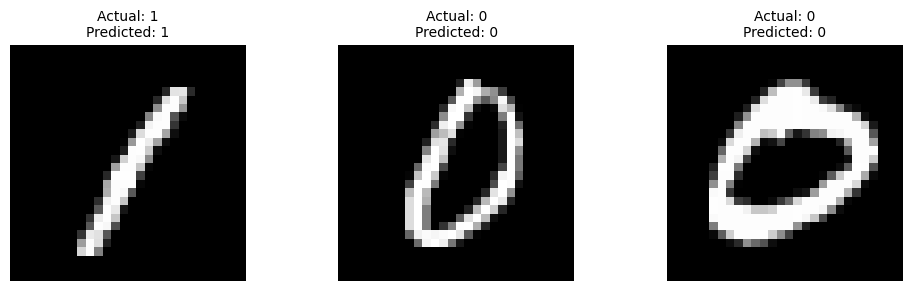


                 COMPLETED


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical


# ============================================================
# 1. LOAD MNIST DATASET
# ============================================================

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("================================================")
print("           ORIGINAL MNIST DATASET")
print("================================================")

print("Original Training Data Shape :", x_train.shape)
print("Original Testing Data Shape  :", x_test.shape)


# ============================================================
# 2. SELECT DIGITS 0, 1 AND 2
# ============================================================

selected_digits = [0, 1, 2]

train_mask = np.isin(y_train, selected_digits)
x_train = x_train[train_mask]
y_train = y_train[train_mask]

test_mask = np.isin(y_test, selected_digits)
x_test = x_test[test_mask]
y_test = y_test[test_mask]

print("\n================================================")
print("        SELECTED DIGITS: 0, 1, 2")
print("================================================")

print("Training Data Shape :", x_train.shape)
print("Testing Data Shape  :", x_test.shape)


# ============================================================
# 3. PREPROCESSING
# ============================================================

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


# ============================================================
# 4. ONE-HOT ENCODING
# ============================================================

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


# ============================================================
# 5. DISPLAY SAMPLE IMAGES
# ============================================================

sample_indices = []

for digit in [0, 1, 2]:

    index = np.where(
        np.argmax(y_train, axis=1) == digit
    )[0][0]

    sample_indices.append(index)


fig, axes = plt.subplots(
    1, 3,
    figsize=(10, 3)
)

for i, index in enumerate(sample_indices):

    digit = np.argmax(y_train[index])

    axes[i].imshow(
        x_train[index].reshape(28, 28),
        cmap="gray"
    )

    axes[i].set_title(
        f"Digit: {digit}\n"
        f"One-Hot: {y_train[index].astype(int)}",
        fontsize=9
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 6. CNN MODEL 1
# FILTERS: 32 -> 64
# ============================================================

model1 = Sequential([

    Input(shape=(28, 28, 1)),

    Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        10,
        activation="softmax"
    )
])


# ============================================================
# 7. COMPILE AND TRAIN MODEL 1
# ============================================================

model1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model1.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=0
)


# ============================================================
# 8. EVALUATE MODEL 1
# ============================================================

loss1, accuracy1 = model1.evaluate(
    x_test,
    y_test,
    verbose=0
)


# ============================================================
# 9. CNN MODEL 2
# FILTERS: 32 -> 64 -> 128
# ============================================================

model2 = Sequential([

    Input(shape=(28, 28, 1)),

    Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        10,
        activation="softmax"
    )
])


# ============================================================
# 10. COMPILE AND TRAIN MODEL 2
# ============================================================

model2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model2.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=0
)


# ============================================================
# 11. EVALUATE MODEL 2
# ============================================================

loss2, accuracy2 = model2.evaluate(
    x_test,
    y_test,
    verbose=0
)


# ============================================================
# 12. MODEL 1 RESULTS
# ============================================================

print("\n================================================")
print("                  MODEL 1 RESULTS")
print("================================================")

print("\nTest Accuracy :", round(accuracy1 * 100, 2), "%")
print("Test Loss     :", round(loss1, 4))

print("\nOne-Hot Encoding")
print("----------------------------")

for digit in [0, 1, 2]:

    index = np.where(
        np.argmax(y_train, axis=1) == digit
    )[0][0]

    print(
        f"Digit {digit} -> "
        f"{y_train[index].astype(int)}"
    )


# ============================================================
# 13. MODEL 2 RESULTS
# ============================================================

print("\n================================================")
print("                  MODEL 2 RESULTS")
print("================================================")

print("\nTest Accuracy :", round(accuracy2 * 100, 2), "%")
print("Test Loss     :", round(loss2, 4))

print("\nOne-Hot Encoding")
print("----------------------------")

for digit in [0, 1, 2]:

    index = np.where(
        np.argmax(y_train, axis=1) == digit
    )[0][0]

    print(
        f"Digit {digit} -> "
        f"{y_train[index].astype(int)}"
    )


# ============================================================
# 14. MODEL COMPARISON
# ============================================================

print("\n================================================")
print("             MODEL COMPARISON")
print("================================================")

print(
    f"{'Model':<15}"
    f"{'Filters':<20}"
    f"{'Accuracy (%)':<15}"
    f"{'Loss'}"
)

print("-" * 62)

print(
    f"{'Model 1':<15}"
    f"{'32 -> 64':<20}"
    f"{accuracy1 * 100:<15.2f}"
    f"{loss1:.4f}"
)

print(
    f"{'Model 2':<15}"
    f"{'32 -> 64 -> 128':<20}"
    f"{accuracy2 * 100:<15.2f}"
    f"{loss2:.4f}"
)


# ============================================================
# 15. VERIFY THREE TEST IMAGES
# ============================================================

# Generate 3 random indices from the test set
random_indices = np.random.choice(len(x_test), 3, replace=False)
verification_indices = random_indices.tolist()


verification_images = x_test[
    verification_indices
]

verification_labels = y_test[
    verification_indices
]


# ============================================================
# 16. PREDICT TEST IMAGES
# ============================================================

predictions = model2.predict(
    verification_images,
    verbose=0
)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

actual_labels = np.argmax(
    verification_labels,
    axis=1
)


# ============================================================
# 17. DISPLAY TEST IMAGES AND PREDICTIONS
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(10, 3)
)

for i in range(3):

    axes[i].imshow(
        verification_images[i].reshape(28, 28),
        cmap="gray"
    )

    axes[i].set_title(
        f"Actual: {actual_labels[i]}\n"
        f"Predicted: {predicted_labels[i]}",
        fontsize=10
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 18. COMPLETED
# ============================================================

print("\n================================================")
print("                 COMPLETED")
print("================================================")